In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Set up openjdk paths for spark

# for MacOS
import os
os.environ['JAVA_HOME'] = '/Library/Java/JavaVirtualMachines/openjdk-17.jdk/Contents/Home'
os.environ['PATH'] = f"{os.environ['JAVA_HOME']}/bin:{os.environ['PATH']}"

In [47]:
# Imports
import geopandas as gpd
from datetime import datetime
from cider.schemas import (
    CallDataRecordData,
    AntennaData,
)
from cider.utils import generate_all_synthetic_data, validate_dataframe, get_spark_session, generate_synthetic_shapefile
from cider.homelocation.schemas import GeographicUnit, GetHomeLocationAlgorithm
from cider.homelocation.core import get_home_locations
from cider.homelocation.plotting import make_location_map

from cider.featurizer.core import preprocess_data

In [44]:
# Step 1: Get data

# Set vars
num_data_points = 2000
num_unqiue_antenna_ids = 100
num_regions = 10
random_seed = 42

spark_session = get_spark_session()

# Generate synthetic data OR load your own data here
synthetic_data = generate_all_synthetic_data(
    num_data_points=num_data_points,
    num_unqiue_antenna_ids=num_unqiue_antenna_ids,
    random_seed=random_seed,
)


shapefile_gdf = generate_synthetic_shapefile(
    antenna_df=synthetic_data[AntennaData],
    num_regions=num_regions,
    random_seed=random_seed,
)

# Validate data
for data_schema, data_df in synthetic_data.items():
    validate_dataframe(data_df, data_schema)

/Users/poornimaramesh/Documents/IDinsight/GiveDirectly_x_Safaricom/cider/src/cider/utils.py:171: Warning: Generating synthetic data for CallDataRecordData schema may result in unrealistic duration values and incompatible antenna values.Use the `correct_generated_synthetic_cdr_data` function to correct these values after generation.
  )
/Users/poornimaramesh/Documents/IDinsight/GiveDirectly_x_Safaricom/cider/src/cider/utils.py:178: Warning: Generating synthetic data for MobileMoneyTransactionData schema may result in unrealistic amount values.Use the `correct_generated_synthetic_mobile_money_transaction_data` function to correct these values after generation.
  )


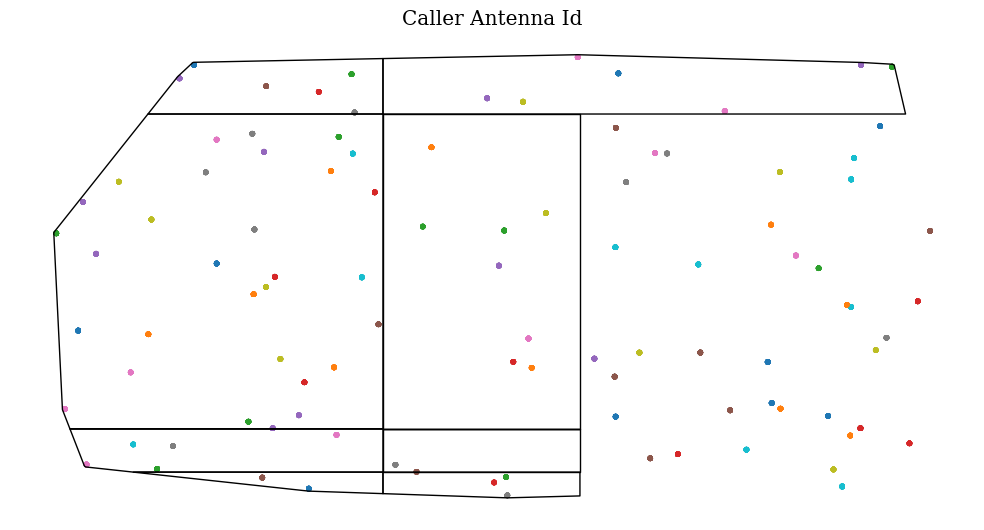

In [45]:
# Step 2: Infer transactions around home antenna

geographic_unit = GeographicUnit.SHAPEFILE
algorithm = GetHomeLocationAlgorithm.COUNT_DAYS

homes_df = get_home_locations(
    spark_session=spark_session,
    cdr_data=synthetic_data[CallDataRecordData],
    antenna_data=synthetic_data[AntennaData],
    shapefile_data=shapefile_gdf,
    geographic_unit=geographic_unit,
    algorithm=algorithm,
    additional_columns_to_keep=[],
)

# Merge home locations with antenna data for plotting
homes_with_antenna_df = homes_df.merge(
    synthetic_data[AntennaData],
    left_on="caller_antenna_id",
    right_on="antenna_id",
    how="left")

homes_with_antenna_gdf = gpd.GeoDataFrame(
    homes_with_antenna_df,
    geometry=gpd.points_from_xy(
        x=homes_with_antenna_df['longitude'],
        y=homes_with_antenna_df['latitude'])
).set_crs(epsg=4326)

make_location_map(
    inferred_home_locations=homes_with_antenna_gdf,
    boundaries_shapefile=shapefile_gdf,
    column_to_plot_label="caller_antenna_id",
    column_to_plot_markersize=algorithm.value,
)

In [ ]:
# Step 3: Featurize data

# Preprocess data

filter_start_date = datetime.strptime("2022-01-05", "%Y-%m-%d")
filter_end_date = datetime.strptime("2025-01-25", "%Y-%m-%d")
spammer_threshold = 1.75
outlier_day_z_score_threshold = 2.0

preprocessed_data = preprocess_data(
    data_dict=synthetic_data,
    filter_start_date=filter_start_date,
    filter_end_date=filter_end_date,
    spammer_threshold=spammer_threshold,
    outlier_day_z_score_threshold=outlier_day_z_score_threshold,
)

# Featurize data

,caller_id,recipient_id,timestamp,duration,transaction_type,transaction_scope,caller_antenna_id,recipient_antenna_id,day
1,caller_id_1,recipient_id_1,2023-12-14,0.000000,text,other,antenna_id_92,antenna_id_45,2023-12-14
2,caller_id_2,recipient_id_2,2023-09-25,906.254581,call,other,antenna_id_14,antenna_id_31,2023-09-25
3,caller_id_3,recipient_id_3,2023-08-07,0.000000,text,international,antenna_id_71,antenna_id_78,2023-08-07
4,caller_id_4,recipient_id_4,2023-02-26,0.000000,text,other,antenna_id_60,antenna_id_79,2023-02-26
5,caller_id_5,recipient_id_5,2023-02-26,0.000000,text,domestic,antenna_id_20,antenna_id_53,2023-02-26
...,...,...,...,...,...,...,...,...,...
1995,caller_id_1995,recipient_id_1995,2023-08-28,442.107035,call,domestic,antenna_id_85,antenna_id_16,2023-08-28
1996,caller_id_1996,recipient_id_1996,2023-12-16,0.000000,text,domestic,antenna_id_50,antenna_id_33,2023-12-16
1997,caller_id_1997,recipient_id_1997,2023-01-26,394.572315,call,domestic,antenna_id_87,antenna_id_15,2023-01-26
1998,caller_id_1998,recipient_id_1998,2023-01-21,529.940587,call,domestic,antenna_id_40,antenna_id_59,2023-01-21
